# Atrasando a entrada


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carrega e prepara os dados
data = pd.read_csv("../DataSpline.csv")
data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data["thetaLag"] = data["theta(Wd,We)"].shift(1)
data = data.iloc[1:]

In [54]:
import matplotlib.pyplot as plt

PREDICTORS = ["Wd", "We"]
TARGET = ["theta(Wd,We)", "thetaLag"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    predictor_colors = plt.cm.tab10.colors
    target_colors = plt.cm.Set2.colors

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot preditores no eixo esquerdo (sem interpolação)
    for i, preds in enumerate(PREDICTORS):
        ax1.plot(df.index, df[preds], marker="o", linestyle="None", label=preds,
                 color=predictor_colors[i % len(predictor_colors)],
                 markersize=5)

    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")
    ax1.tick_params(axis='y', labelcolor="black")

    # Plot alvos no eixo direito (sem interpolação)
    if PlotOut:
        ax2 = ax1.twinx()
        for i, target in enumerate(TARGET):
            ax2.plot(df.index, df[target], marker="o", linestyle="None", label=target,
                     color=target_colors[i % len(target_colors)],
                     markersize=5)
        ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")
        ax2.tick_params(axis='y', labelcolor="gray")

    # Legendas
    leg1 = ax1.legend(loc="upper left", title="Preditores")
    ax1.add_artist(leg1)
    if PlotOut:
        ax2.legend(loc="upper right", title="Alvos")

    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"content/figs/{img_name}", format="svg", dpi=600)
    plt.show()


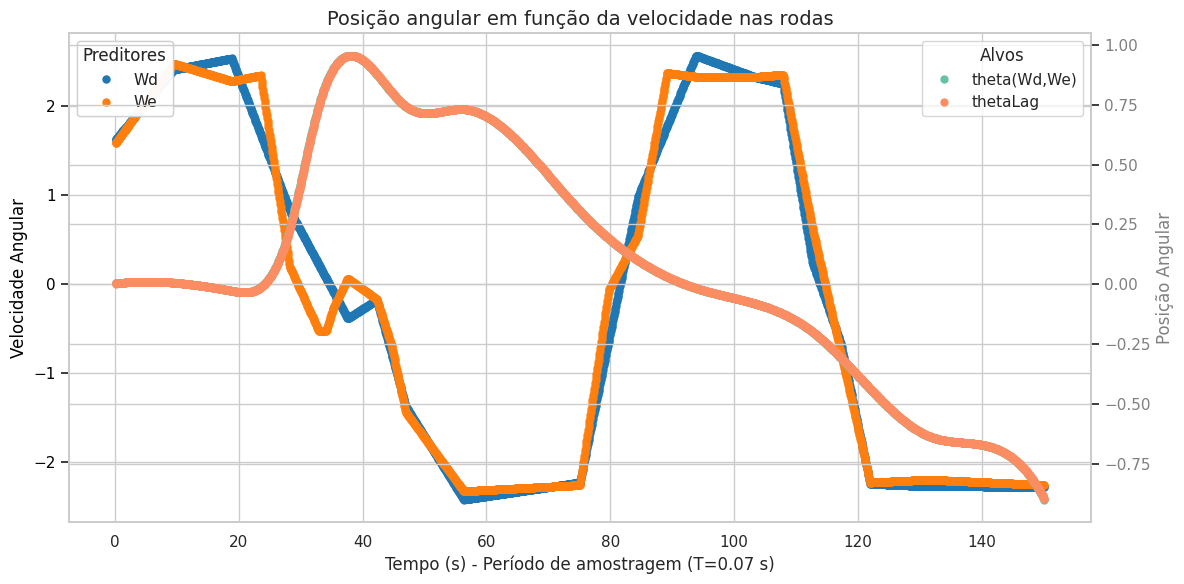

In [55]:
PlotTimeSeries(data)

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pykrige.ok3d import OrdinaryKriging3D
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

PREDICTORS = ["Wd", "We", "thetaLag"]
TARGET = "theta(Wd,We)"
VARIOGRAMS = ["gaussian", "spherical", "exponential", "power", "linear", "hole-effect"]

class Kriging3D:
    
    def __init__(self, Dataset):
        # Separação dos dados em treino/teste
        train_data, test_data = train_test_split(Dataset, test_size=0.25, shuffle=False)

        # Padronizadores
        self.x_scaler = StandardScaler().fit(train_data[PREDICTORS])
        self.y_scaler = StandardScaler().fit(train_data[[TARGET]])

        # Normalizando os dados
        self.train_samples_x = self.x_scaler.transform(train_data[PREDICTORS])
        self.train_samples_y = self.y_scaler.transform(train_data[[TARGET]]).ravel()
        
        self.test_samples_x = self.x_scaler.transform(test_data[PREDICTORS])
        self.test_samples_y = self.y_scaler.transform(test_data[[TARGET]]).ravel()
        
        # Armazenar tempos para plotagem
        self.train_time = train_data.index
        self.test_time = test_data.index

        self.kriging_model = None

    def BuildModel(self, VariogramType):
        self.kriging_model = OrdinaryKriging3D(
            self.train_samples_x[:, 0],
            self.train_samples_x[:, 1],
            self.train_samples_x[:, 2],
            self.train_samples_y,
            variogram_model=VariogramType
        )
    
    def ComputeMetrics(self):
        # Previsões em pontos
        train_pred = self.kriging_model.execute(
            'points',
            self.train_samples_x[:, 0],
            self.train_samples_x[:, 1],
            self.train_samples_x[:, 2]
        )[0]

        test_pred = self.kriging_model.execute(
            'points',
            self.test_samples_x[:, 0],
            self.test_samples_x[:, 1],
            self.test_samples_x[:, 2]
        )[0]

        # Desnormalização
        self.train_pred = self.y_scaler.inverse_transform(train_pred.reshape(-1, 1)).ravel()
        self.test_pred = self.y_scaler.inverse_transform(test_pred.reshape(-1, 1)).ravel()
        train_y_orig = self.y_scaler.inverse_transform(self.train_samples_y.reshape(-1, 1)).ravel()
        test_y_orig = self.y_scaler.inverse_transform(self.test_samples_y.reshape(-1, 1)).ravel()

        # Métricas
        return {
            'r2_training': r2_score(train_y_orig, self.train_pred),
            'mse_training': mean_squared_error(train_y_orig, self.train_pred),
            'mape_training': mean_absolute_percentage_error(train_y_orig, self.train_pred),
            'rmse_training': root_mean_squared_error(train_y_orig, self.train_pred),

            'r2_test': r2_score(test_y_orig, self.test_pred),
            'mse_test': mean_squared_error(test_y_orig, self.test_pred),
            'mape_test': mean_absolute_percentage_error(test_y_orig, self.test_pred),
            'rmse_test': root_mean_squared_error(test_y_orig, self.test_pred),
        }

    def PlotOut(self, variogram):
        colors = plt.cm.tab10.colors
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        ax1.plot(self.train_time, self.train_pred, marker="o", label="train_pred", color=colors[0])
        ax1.plot(self.train_time, self.y_scaler.inverse_transform(self.train_samples_y.reshape(-1, 1)).ravel(),
                 marker="o", label="train_orig", color=colors[1])
        ax1.set_title("Dados de Treinamento")
        ax1.set_xlabel("Tempo (s)")
        ax1.set_ylabel("Velocidade Angular")
        ax1.legend()
        ax1.grid(True)

        ax2.plot(self.test_time, self.test_pred, marker="o", label="test_pred", color=colors[2])
        ax2.plot(self.test_time, self.y_scaler.inverse_transform(self.test_samples_y.reshape(-1, 1)).ravel(),
                 marker="o", label="test_orig", color=colors[3])
        ax2.set_title("Dados de Teste")
        ax2.set_xlabel("Tempo (s)")
        ax2.legend()
        ax2.grid(True)

        fig.suptitle(f"Resultados do modelo Kriging 3D: {variogram}")
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(f"content/figs/{variogram}.svg", format="svg", dpi=600)
        plt.show()

    def EvalModel(self, excel_path):
        self.models = {}
        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            for variogram in VARIOGRAMS:
                self.BuildModel(VariogramType=variogram)
                metrics = self.ComputeMetrics()
                self.models[variogram] = self.kriging_model

                display(metrics)
                df = pd.DataFrame([metrics])
                df.to_excel(writer, sheet_name=variogram, index=False)
                self.PlotOut(variogram)


/usr/local/python/3.12.1/lib/python3.12/site-packages/pykrige/core.py:825: RuntimeWarning: invalid value encountered in sqrt
  sigma[i] = np.sqrt(ss)


{'r2_training': -101193425.23026909,
 'mse_training': 12906179.903911514,
 'mape_training': 96321.00580505849,
 'rmse_training': 3592.517209967339,
 'r2_test': -1.0847462865829773e+19,
 'mse_test': 3.29149342602418e+17,
 'mape_test': 752955178.8564858,
 'rmse_test': 573715384.6659665}

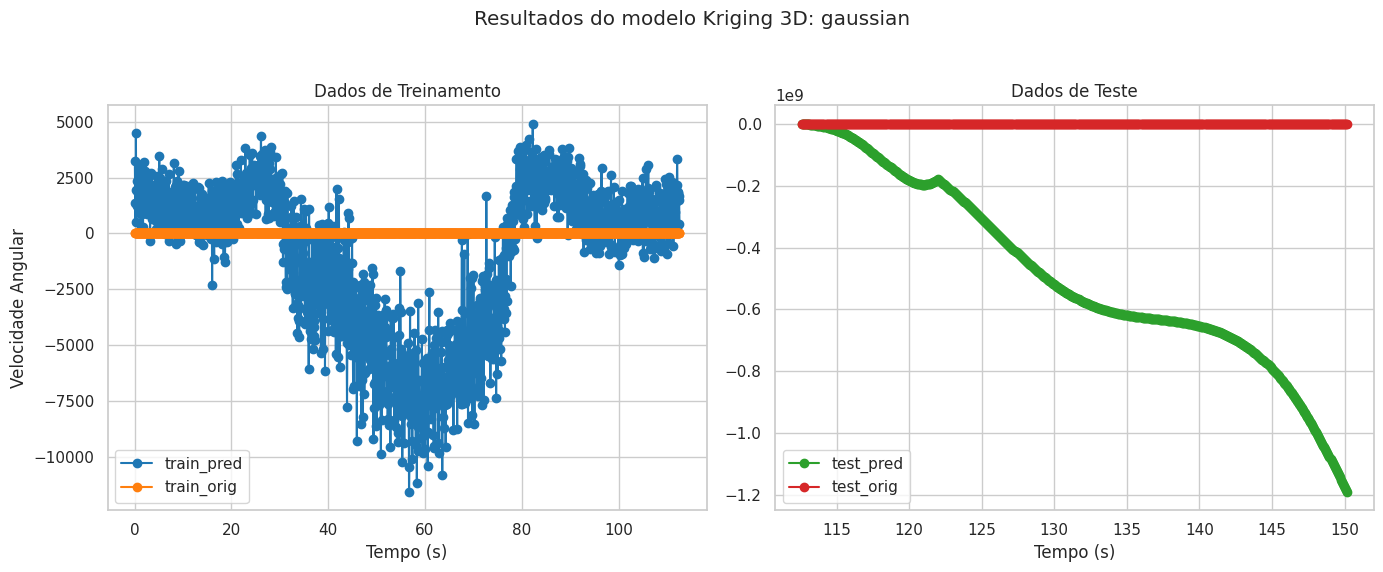

{'r2_training': 1.0,
 'mse_training': 2.2008527679327362e-24,
 'mape_training': 1.2753441225814532e-10,
 'rmse_training': 1.483527137578796e-12,
 'r2_test': -19.13412577218695,
 'mse_test': 0.6109386447097825,
 'mape_test': 1.2136301081481373,
 'rmse_test': 0.7816256423056901}

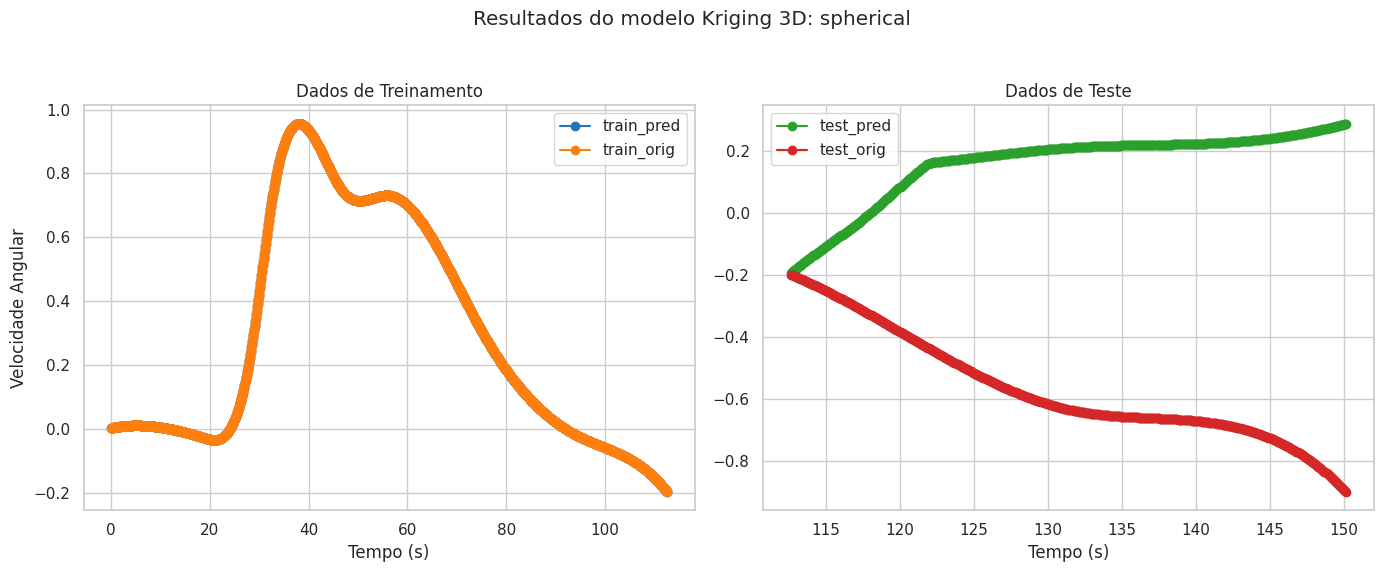

{'r2_training': 1.0,
 'mse_training': 1.5220559480572562e-25,
 'mape_training': 1.7024538946221472e-11,
 'rmse_training': 3.901353544678124e-13,
 'r2_test': -20.876023095858404,
 'mse_test': 0.6637938022760226,
 'mape_test': 1.320364464768482,
 'rmse_test': 0.8147354185722029}

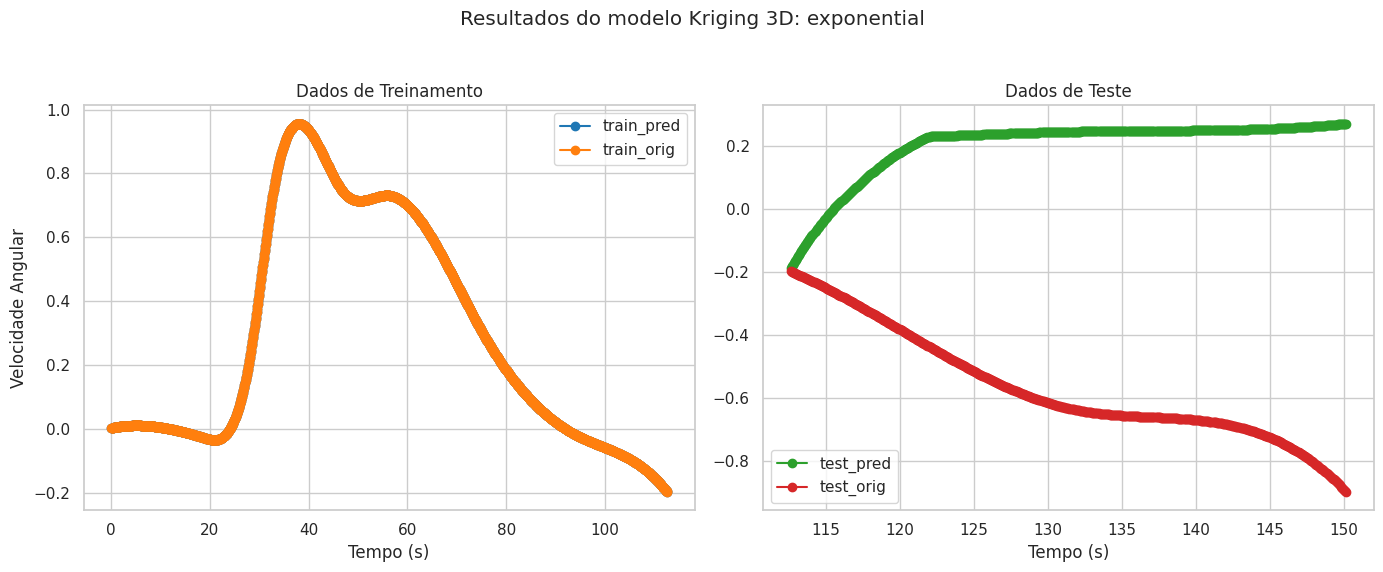

{'r2_training': 1.0,
 'mse_training': 2.8845871185881005e-22,
 'mape_training': 5.597659080076431e-10,
 'rmse_training': 1.6984072299033883e-11,
 'r2_test': -2.6882886545393636,
 'mse_test': 0.11191536684525205,
 'mape_test': 0.5108272072479852,
 'rmse_test': 0.33453754175765094}

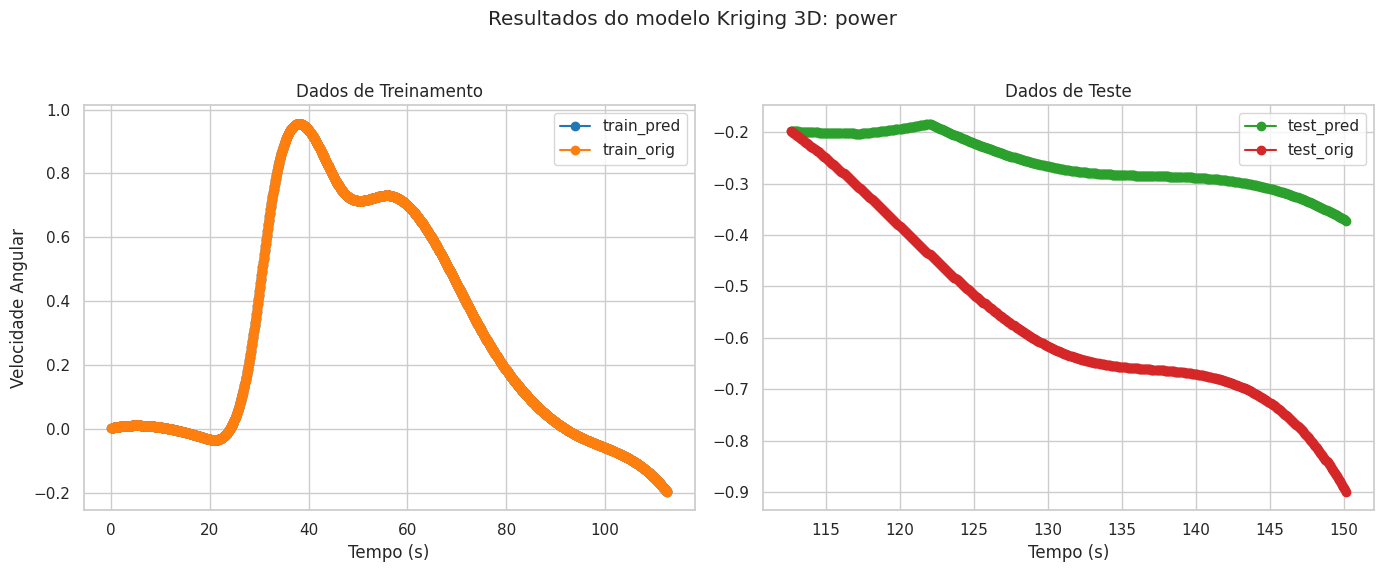

{'r2_training': 1.0,
 'mse_training': 1.1091685932923405e-24,
 'mape_training': 8.619042538641994e-11,
 'rmse_training': 1.053170733211069e-12,
 'r2_test': -6.8732762206169555,
 'mse_test': 0.238902287493112,
 'mape_test': 0.7643395090495743,
 'rmse_test': 0.4887763164200082}

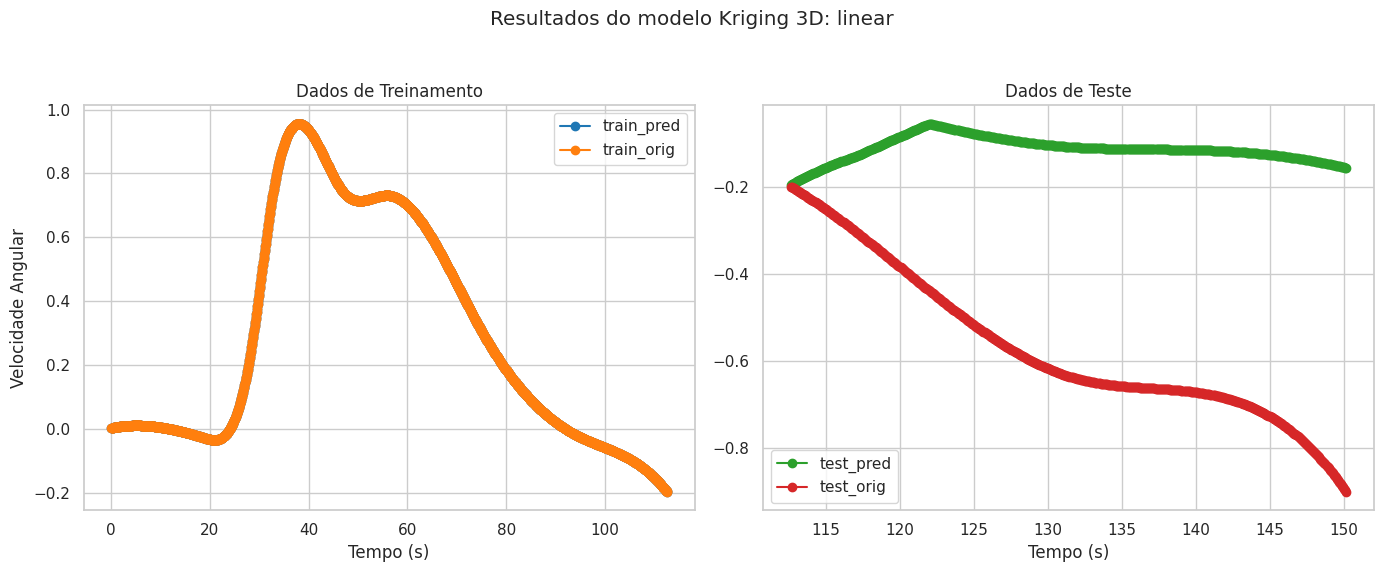

{'r2_training': 1.0,
 'mse_training': 2.5005969423994746e-25,
 'mape_training': 1.1857936386527596e-11,
 'rmse_training': 5.000596906769705e-13,
 'r2_test': -28.564398583685094,
 'mse_test': 0.8970855654099009,
 'mape_test': 1.585681306627227,
 'rmse_test': 0.9471460106076047}

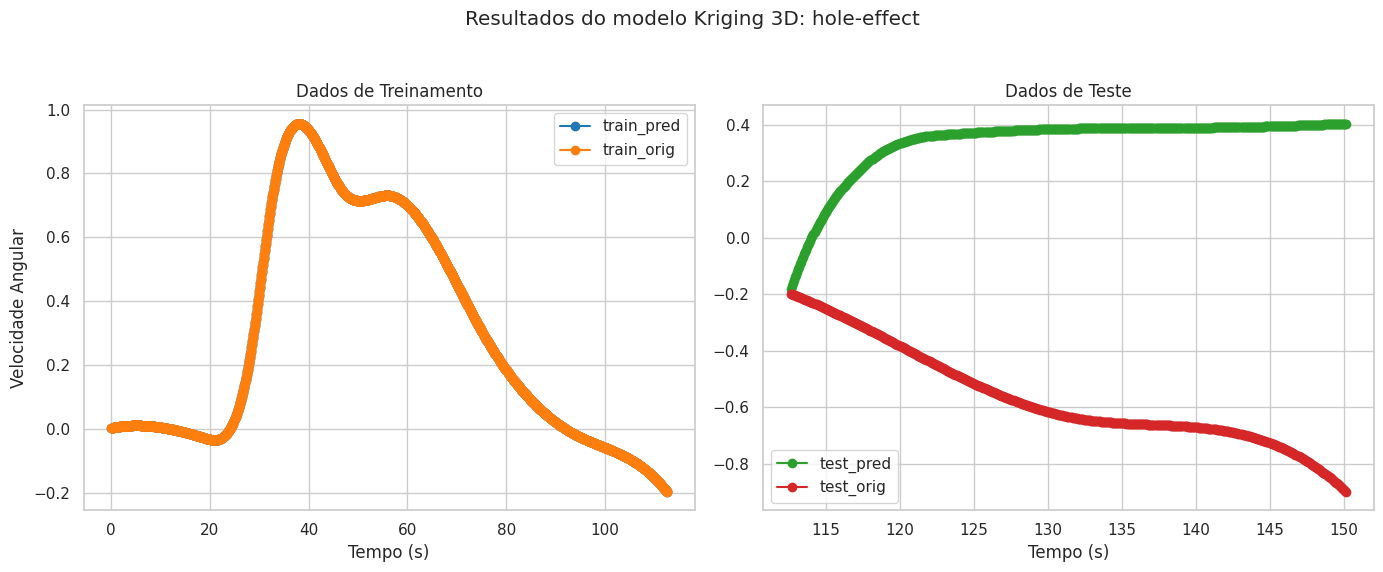

In [57]:
Vsg = Kriging3D(Dataset=data)        
Vsg.EvalModel("./content/KrigingMetrics.xlsx")